In [1]:
from src import load_material as tools
from src import lambda_interpolate as interp
import numpy as np
import matplotlib.pyplot as plt
import miepython as mie
import pandas as pd

In [25]:
material = "materials/silicon.csv"

refrative_index_df = pd.read_csv(material, delimiter = ",", header = 0, names = ["wl", "n", "k"], dtype = float)

wl_step = 5 # nm step size between each wl sample
wavelengths = np.arange(200, refrative_index_df['wl'].max()*1e3, wl_step) *1e-3 # wavelength range to me tested with
n, k = interp.wvl_interpolation(wavelengths, 
                                refrative_index_df['wl'], 
                                refrative_index_df['n'],
                                refrative_index_df['k'],
                                )

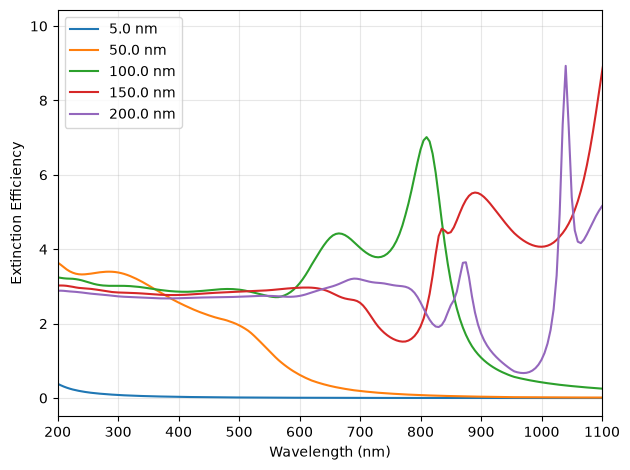

In [26]:
r_range = [0.005, 0.05, 0.1, 0.15,  0.2]  # in microns
m = n - 1.0j * k # complex refractive index

fig, ax = plt.subplots()

for radii in r_range:
    x = 2 * np.pi * radii / wavelengths
    cross_section_area = np.pi * radii**2
    qext, qsca, qback, g = mie.efficiencies_mx(m, x)
    ax.plot(wavelengths*1e3, qext, label=f"{radii*1e3} nm")

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Extinction Efficiency')
ax.set_xlim(wavelengths.min()*1e3,1100)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
